# **4.x Notebook**

Comprehensive (hopefully) notebook for project up to the current point. WIP
by Jack Phelan  




## Table of Contents
1. [Setup](#setup)
2. [Data Preparation](#data-preparation)
   - [Loading default df and applying EDA preprocessing steps](#loading-default-df-and-applying-eda-preprocessing-steps)
   - [Creating factor transformed dataset for 1.0 dataset](#creating-factor-transformed-dataset-for-10-dataset)
   - [Creating CFA based dataset with v1 base](#creating-cfa-based-dataset-with-v1-base)
3. [MLFlow Integrations](#mlflow-integrations)

## **Setup**

In [101]:
# ── standard library ─────────────────────────────────────────────────────────
import re
import sys
import json
import datetime
from contextlib import contextmanager
from pathlib import Path
from types import SimpleNamespace
import os

# ── data & numeric ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ── ML ────────────────────────────────────────────────────────────────────────
import gcsfs
import joblib
import mord
import lightgbm as lgb
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    f1_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import mlflow
import mlflow.data
from factor_analyzer import FactorAnalyzer, ConfirmatoryFactorAnalyzer, ModelSpecificationParser



# ── project ───────────────────────────────────────────────────────────────────
from src.modeling.eval import evaluate_binary as evaluate, evaluate_multiclass as evaluate_mc, tag_comparison_df as _tag
from src.features import raw_data_loader, feature_encoder
from src.features.transformers import Factor_Analyzer_Transformer
from src.modeling.fa_tuning import tune_factor_analysis_rotation, build_best_factor_analysis_pipeline
from src.utils.data_utils import convert_ahi, make_multiclass_y


## **Data Preparation**


### Loading default df and applying EDA preprocessing steps

In [102]:
# This is the default 1.0 dataset that will be iterated upon in future experiments.
raw_df = raw_data_loader.load_and_clean_raw("../..")
encoded_df = feature_encoder.encode_features(raw_df)
encoded_df = encoded_df.drop(columns=["ess_total_score", "isi_total_score"])
encoded_df.to_csv("../../data/processed/mlflow/mlflow_dataset_v1.csv", index=False)

### Creating factor transformed dataset for 1.0 dataset

In [103]:
# performing factor analysis
factor_analyzer = FactorAnalyzer(n_factors=18, rotation="quartimax")

encoded_df  = pd.read_csv("../../data/processed/mlflow/mlflow_dataset_v1.csv")
encoded_features = encoded_df.drop(columns=["ahi"])
encoded_target = encoded_df["ahi"]
factor_analyzer.fit(encoded_features)
fa_loadings = pd.DataFrame(factor_analyzer.loadings_, index=encoded_features.columns
)

In [104]:
# display top n features per factor loading
n = 7

top_features = {}
for factor in fa_loadings.columns:
    top = fa_loadings[factor].abs().nlargest(n)
    top_features[factor] = [f"{feat}  ({fa_loadings.loc[feat, factor]:+.2f})" for feat in top.index]

pd.DataFrame(top_features, index=[f"#{i+1}" for i in range(n)])


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
#1,fati_interferes_with_work_fam_social_fss (+0.90),diff_staying_asleep_isi (+0.75),not_able_to_control_worrying_freq_gad (+0.75),ess_chance_of_dozing_inactive_public (+0.62),map_index_1_apnea_score (+1.01),feel_sleep_not_sound_isq (+0.78),troub_brth_nose (+0.84),age (+0.59),family_history_of_psychiatric_treatment_mdhx ...,map_index_4_narcolepsy_like_symptoms_score (+...,bmi (+0.77),sleep_affected_your_social_life_isq (+0.47),dream_recall_frequency_rarely_or_never (-0.74),sex (+0.40),ess_chance_of_dozing_lying_down_in_afternoon_w...,latency_sw (+0.42),never_feel_rested (-0.33),difficulty_watching_a_movie_fosq (+0.41)
#2,fati_causes_freq_probs_for_me_fss (+0.89),troub_slp_nose (+0.67),worry_too_much_diff_things_freq_gad (+0.72),ess_chance_of_dozing_in_a_car_while_stopped_fo...,snorting_gasping_map (+0.81),difficulty_staying_asleep_isq (+0.76),nasal_blockage_obstr_nose (+0.80),hypercholesterolemia_mdhx (+0.48),family_history_of_depression_mdhx (+0.64),hh_frequency_score (+0.73),map_score (+0.68),sleep_affected_other_important_parts_of_life_i...,dream_recall_frequency_infrequent (+0.68),morning_headache_map (+0.26),frequent_naps (+0.42),diff_falling_asleep_isi (+0.34),rmeq_total_score (+0.31),ess_chance_of_dozing_tv (-0.35)
#3,fati_interferes_with_responsibilities_fss (+0...,diff_falling_asleep_isi (+0.64),feeling_anxious_freq_gad (+0.67),ess_chance_of_dozing_sitting_quietly_after_lun...,breathing_stops_map (+0.72),multiple_awakenings_isq (+0.74),nasal_congestion_stuffiness_nose (+0.74),hypertension_mdhx (+0.45),family_history_of_anxiety_mdhx (+0.58),sleep_paralysis_frequency_score (+0.67),map_likelihood_ration (+0.52),sleep_affected_work_isq (+0.44),never_smoked (+0.23),feel_depressed_freq_phq (-0.26),difficulty_operating_motor_vehicles_for_short_...,diff_falling_asleep_isq (+0.33),feel_sleep_unrefreshing_isq (-0.29),difficulty_being_active_in_evening_fosq (+0.32)
#4,fati_top_three_disabling_sympts_fss (+0.85),diff_falling_asleep_isq (+0.62),feel_as_if_awful_might_happen_freq_gad (+0.60),fall_asleep_driving_map (+0.57),loud_snoring_map (+0.67),feel_sleep_unrefreshing_isq (+0.74),not_enough_air_excercise_nose (+0.62),cardiovascular_problem_other_mdhx (+0.41),family_history_of_other_psychiatric_illness_md...,fall_asleep_driving_map (+0.28),hypertension_mdhx (+0.31),sleep_made_you_irritable_isq (+0.40),frequent_naps (+0.17),thought_you_would_be_better_dead_freq_phq (-0...,ess_chance_of_dozing_sitting_and_reading (+0.29),how_satisfied_with_curr_sleep_pattern_isi (-0...,difficulty_staying_asleep_isq (+0.22),rmeq_total_score (-0.29)
#5,fati_interferes_with_phys_function_fss (+0.84),how_satisfied_with_curr_sleep_pattern_isi (+0...,feel_bad_abt_yourself_freq_phq (+0.58),map_index_3_excessive_daytime_sleepiness_ (+0...,map_score (+0.60),sleep_made_you_fatigued_isq (+0.47),allergies_or_sinus_problems_mdhx (+0.42),medical_problem_or_surgery_other_mdhx (+0.41),family_history_of_insomnia_mdhx (+0.32),map_index_3_excessive_daytime_sleepiness_ (+0...,exercise_amt_or_time (-0.27),sleep_caused_trouble_concentrating_isq (+0.39),frequent_daytime_sleepiness (+0.15),gastrointestinal_problem_or_surgery_mdhx (+0.23),difficulty_operating_motor_vehicles_for_long_d...,sex (+0.21),difficulty_being_active_in_morning_fosq (+0.22),effect_on_desire_for_intimacy_or_sex_fosq (+0...
#6,fati_prevents_sustained_phys_func_fss (+0.83),slp_quality_sw (-0.54),trouble_relaxing_freq_gad (+0.57),difficulty_operating_motor_vehicles_for_short_...,frequent_tossing_turning_map (+0.31),sleep_affected_your_social_life_isq (+0.30),ear_nose_and_throat_problem_or_surgery_other_m...,urologic_or_kidney_problem_mdhx (+0.34),family_history_of_fibromyalgia_or_chronic_fati...,morning_headache_map (+0.24),type_2_diabetes_mdhx (+0.22),sleep_made_you_fatigued_isq (+0.25),family_history_of_sleep_apnea_mdhx (+0.13),little_interest_or_pleasure_freq_phq (-0.21),ess_chance_of_dozing_tv (+0.25),rmeq_total_score (-0.20),feel_refreshed_after_nap (+0.22

In [105]:
fa_df = factor_analyzer.transform(encoded_features)
fa_df = pd.DataFrame(fa_df, columns=[f"Factor_{i+1}" for i in range(fa_df.shape[1])])
fa_df["ahi"] = encoded_target.values

fa_df.to_csv("../../data/processed/mlflow/mlflow_factor_dataset_v1.csv", index=False)

display(fa_df.head(5))


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15,Factor_16,Factor_17,Factor_18,ahi
0,35.766926,469.093860,-127.427710,911.196915,-3435.227408,-53.878825,199.330406,298.385842,-199.259447,651.468553,992.251477,34.591764,57.768046,77.941877,287.483926,-359.482086,142.346987,939.855590,0.3
1,323.854888,4195.291566,-1138.819720,8137.205140,-30744.337813,-490.166215,1790.764602,2676.898070,-1772.794579,5828.636113,8878.954965,310.146927,530.676634,686.210360,2569.776663,-3206.147546,1268.130313,8383.749697,0.4
2,-223.558856,-2914.739177,789.632700,-5658.463044,21369.494992,340.364690,-1246.176703,-1861.455930,1232.266396,-4053.484426,-6173.226013,-212.937160,-368.295586,-476.402247,-1787.902763,2229.786529,-881.470189,-5828.833304,1.0
3,-37.046131,-467.733177,128.692537,-909.541972,3433.387856,54.428891,-200.591382,-298.920519,198.294410,-649.286992,-992.362742,-34.220449,-59.547808,-75.840732,-287.886898,358.228540,-142.979521,-937.488593,3.9
4,41.470517,544.550645,-147.099404,1056.064349,-3993.485146,-64.505173,233.242283,347.471861,-229.042355,756.616701,1155.756794,40.741331,68.909986,89.147731,333.861565,-418.182822,165.603702,1086.883448,1.3


### Creating CFA based dataset with v1 base

In [106]:
# Build CFA model spec from EFA results:
# assign each feature to its highest absolute-loading factor
factor_assignments = fa_loadings.abs().idxmax(axis=1)

model_dict = {}
for factor_col in fa_loadings.columns:
    assigned = factor_assignments[factor_assignments == factor_col].index.tolist()
    if assigned:
        model_dict[f"F{factor_col + 1}"] = assigned  # use string names; fa_loadings cols are 0-indexed ints

# first arg must be the data (not n_factors) so the parser can infer variable count/order
model_spec = ModelSpecificationParser.parse_model_specification_from_dict(
    encoded_features, model_dict
)

confirmatory_factor_analyzer = ConfirmatoryFactorAnalyzer(model_spec, disp=False, max_iter=1000)
confirmatory_factor_analyzer.fit(encoded_features.values)

cfa_loadings = pd.DataFrame(
    confirmatory_factor_analyzer.loadings_,
    index=encoded_features.columns,
    columns=list(model_dict.keys()),
)

print(f"CFA fitted: {len(model_dict)} factors over {len(encoded_features.columns)} variables")
display(cfa_loadings)


CFA fitted: 17 factors over 146 variables


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/factor_analyzer/confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
  warnings.warn(


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F13,F14,F15,F16,F17,F18
age,1.092910,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
bmi,1.113966,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
sex,0.926638,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
sw_9am_start_diff,0.976828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
sw_5pm_end_diff,0.985247,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
congestive_heart_failure_mdhx,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.934095,0.000000
hypertension_mdhx,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.960243,0.000000
oophorectomy_bilateral_mdhx,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.937328,0.000000
dream_recall_frequency_infrequent,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.954623,0.000000


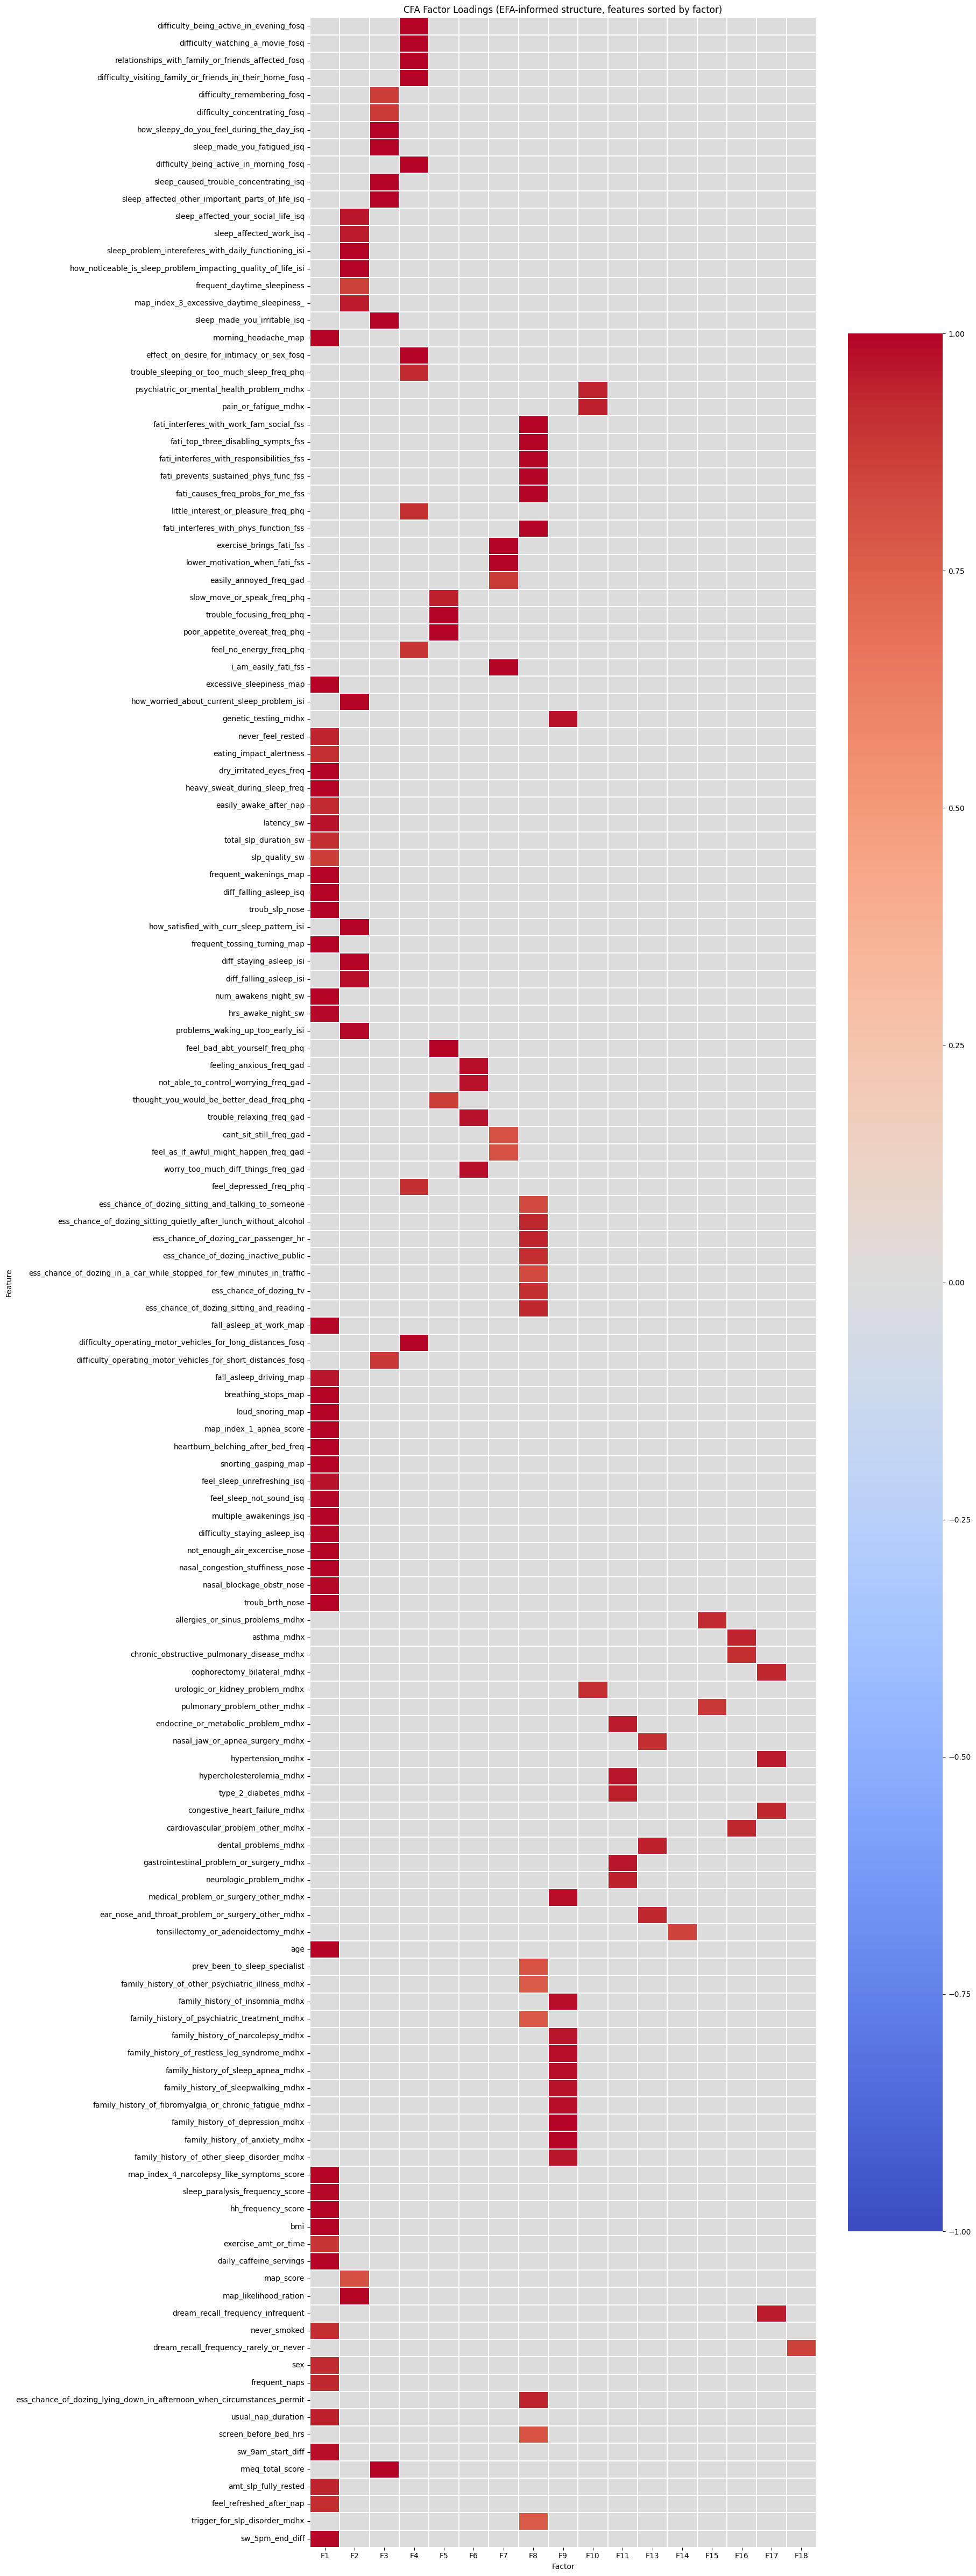

In [107]:
# Sort features by factor assignment for block-diagonal structure
sort_order = factor_assignments.map({col: i for i, col in enumerate(fa_loadings.columns)})
sorted_features = sort_order.sort_values().index
cfa_loadings_sorted = cfa_loadings.loc[sorted_features]

fig, ax = plt.subplots(figsize=(18, max(10, len(encoded_features.columns) // 3)))
sns.heatmap(
    cfa_loadings_sorted,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    ax=ax,
)
ax.set_title("CFA Factor Loadings (EFA-informed structure, features sorted by factor)")
ax.set_xlabel("Factor")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


In [108]:
cfa_scores = confirmatory_factor_analyzer.transform(encoded_features.values)
cfa_df = pd.DataFrame(cfa_scores, columns=list(model_dict.keys()))
cfa_df["ahi"] = encoded_target.values

cfa_dataset_path = "../../data/processed/mlflow/mlflow_cfa_dataset_v1.csv"
cfa_df.to_csv(cfa_dataset_path, index=False)

print(f"CFA dataset saved to {cfa_dataset_path}  shape={cfa_df.shape}")
display(cfa_df.head(5))


CFA dataset saved to ../../data/processed/mlflow/mlflow_cfa_dataset_v1.csv  shape=(1687, 18)


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F13,F14,F15,F16,F17,F18,ahi
0,-0.143716,-0.104106,0.082198,0.310315,-0.156887,-0.066842,-0.168565,-0.124902,-0.185536,-0.300405,-0.205800,-0.244269,-0.292704,-0.238758,-0.132812,-0.165508,0.585288,0.3
1,-0.496754,0.223433,0.453341,-0.981626,-0.343780,-0.590463,0.490244,0.563383,0.357905,0.770250,-0.205800,-0.244269,-0.292704,-0.238758,-0.132812,0.076625,-0.570896,0.4
2,-0.100753,0.981688,0.921126,-0.245896,-0.136531,-0.100637,0.183422,-0.311052,-0.185536,-0.300405,-0.205800,0.461106,0.874651,-0.238758,-0.132812,-0.165508,0.585288,1.0
3,0.053249,-0.516036,-0.086786,-0.100491,0.311715,1.176224,-0.446000,-0.995069,-0.004060,0.410342,-0.006082,-0.244269,-0.292704,-0.238758,-0.132812,-0.165508,0.585288,3.9
4,-0.495538,-0.405588,0.519192,-0.272442,0.051571,0.196574,0.180937,-0.330084,0.169108,0.053340,-0.205800,0.100875,-0.292704,0.310243,-0.132812,0.079199,0.585288,1.3


## TODO: 
- figure out what cfa dataset has been made 
- make a dataset of just the features cfa has decided to be most important  

## **Feature Importances of EFA and CFA Datasets**

In [109]:
from sklearn.inspection import permutation_importance
import time

"""
Helper function to compute and display permutation importances for a given model and dataset.
- model: fitted model to evaluate
- X: feature dataframe
- y: target series
- vis: whether to plot the importances
- kwargs: additional arguments to pass to permutation_importance (e.g. scoring metric)
"""
def permutation_importance_function(model, X, y, vis=True, **kwargs):
    start_time = time.time()
    result = permutation_importance(
        model, X, y, n_repeats=20, random_state=42, n_jobs=2, **kwargs
    )
    elapsed_time = time.time() - start_time
    print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

    forest_importances = pd.Series(result.importances_mean, index= X.columns)
    display(forest_importances.sort_values(ascending=False))
    
    if vis:
        fig, ax = plt.subplots()
        forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
        ax.set_title("Feature importances using permutation on full model")
        ax.set_ylabel("Mean accuracy decrease")
        fig.tight_layout()
        plt.show()


## EFA Dataset Feature Importances

In [110]:
# get feature importances from efa and cfa datasets
rf_model = RandomForestClassifier(n_estimators=500, random_state=42)

fa_X = fa_df.drop(columns=["ahi"])
fa_y = fa_df["ahi"]
fa_y = convert_ahi(fa_y, threshold=15)

fa_X_train, fa_test_X, fa_train_y, fa_test_y = train_test_split(fa_X, fa_y, test_size=0.2, random_state=42)
rf_model.fit(fa_X_train, fa_train_y)
fa_importances = pd.Series(rf_model.feature_importances_, index=fa_X.columns).sort_values(ascending=False)

display(fa_importances)

2026/05/26 11:35:45 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f24dd8da55764bdf8d44f3025ca7a6b0', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/05/26 11:35:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Factor_1     0.071794
Factor_12    0.064804
Factor_6     0.063199
Factor_13    0.059278
Factor_14    0.058901
Factor_3     0.056448
Factor_17    0.053780
Factor_7     0.053722
Factor_16    0.053469
Factor_5     0.052946
Factor_15    0.052577
Factor_9     0.052011
Factor_4     0.051783
Factor_2     0.051735
Factor_10    0.051502
Factor_8     0.050967
Factor_11    0.050896
Factor_18    0.050187
dtype: float64

/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Elapsed time to compute the importances: 5.424 seconds


Factor_10    0.004882
Factor_7     0.003994
Factor_9     0.002071
Factor_16    0.000592
Factor_14   -0.003254
Factor_13   -0.003698
Factor_18   -0.003994
Factor_12   -0.004586
Factor_4    -0.004734
Factor_11   -0.004882
Factor_2    -0.005178
Factor_17   -0.006065
Factor_1    -0.007249
Factor_15   -0.007544
Factor_5    -0.007988
Factor_8    -0.008728
Factor_3    -0.008876
Factor_6    -0.011686
dtype: float64

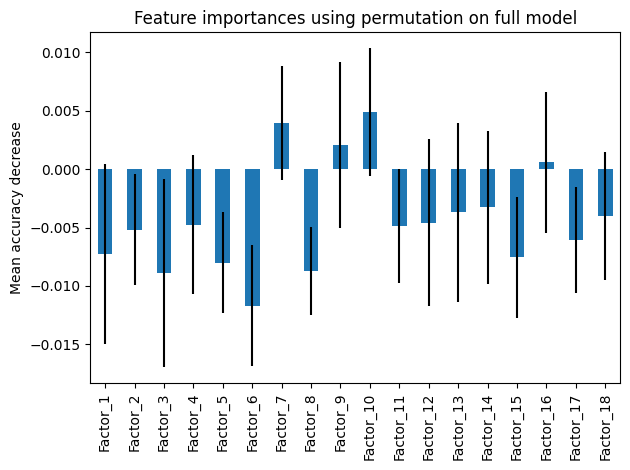

In [111]:
permutation_importance_function(rf_model, fa_test_X, fa_test_y)

In [112]:
# look at top loadings for factors 7, 9, 10, 16
# fa_loadings columns are 0-indexed ints, so Factor_N = index N-1
columns_of_interest = [6, 8, 9, 15]
fa_loadings_subset = fa_loadings[columns_of_interest]

n = 7
top_features = {}
for factor in fa_loadings_subset.columns:
    top = fa_loadings_subset[factor].abs().nlargest(n)
    top_features[f"Factor_{factor+1}"] = [f"{feat}  ({fa_loadings_subset.loc[feat, factor]:+.2f})" for feat in top.index]

pd.DataFrame(top_features, index=[f"#{i+1}" for i in range(n)])

,Factor_7,Factor_9,Factor_10,Factor_16
#1,troub_brth_nose (+0.84),family_history_of_psychiatric_treatment_mdhx ...,map_index_4_narcolepsy_like_symptoms_score (+...,latency_sw (+0.42)
#2,nasal_blockage_obstr_nose (+0.80),family_history_of_depression_mdhx (+0.64),hh_frequency_score (+0.73),diff_falling_asleep_isi (+0.34)
#3,nasal_congestion_stuffiness_nose (+0.74),family_history_of_anxiety_mdhx (+0.58),sleep_paralysis_frequency_score (+0.67),diff_falling_asleep_isq (+0.33)
#4,not_enough_air_excercise_nose (+0.62),family_history_of_other_psychiatric_illness_md...,fall_asleep_driving_map (+0.28),how_satisfied_with_curr_sleep_pattern_isi (-0...
#5,allergies_or_sinus_problems_mdhx (+0.42),family_history_of_insomnia_mdhx (+0.32),map_index_3_excessive_daytime_sleepiness_ (+0...,sex (+0.21)
#6,ear_nose_and_throat_problem_or_surgery_other_m...,family_history_of_fibromyalgia_or_chronic_fati...,morning_headache_map (+0.24),rmeq_total_score (-0.20)
#7,asthma_mdhx (+0.19),psychiatric_or_mental_health_problem_mdhx (+0...,fall_asleep_at_work_map (+0.18),sleep_problem_intereferes_with_daily_functioni...


## CFA Dataset Feature Importances

In [113]:
cfa_X = cfa_df.drop(columns=["ahi"])
cfa_y = cfa_df["ahi"]
cfa_y = convert_ahi(cfa_y, threshold=15)
cfa_X_train, cfa_test_X, cfa_train_y, cfa_test_y = train_test_split(cfa_X, cfa_y, test_size=0.2, random_state=42)
rf_model.fit(cfa_X_train, cfa_train_y)
cfa_importances = pd.Series(rf_model.feature_importances_, index=cfa_X.columns).sort_values(ascending=False)
display(cfa_importances)

2026/05/26 11:35:54 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'c0db4c05a0324131aae531339c33d9df', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/26 11:35:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


F1     0.122963
F2     0.106314
F3     0.101586
F8     0.094358
F7     0.083305
F4     0.082814
F9     0.072517
F5     0.060466
F6     0.060063
F11    0.049931
F17    0.032628
F10    0.032281
F13    0.031367
F16    0.025472
F15    0.018228
F14    0.013250
F18    0.012455
dtype: float64

/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Elapsed time to compute the importances: 4.819 seconds


F1     0.017160
F8     0.016420
F2     0.012870
F10    0.006065
F9     0.005178
F4     0.005030
F11    0.004882
F3     0.004734
F6     0.003402
F17    0.003254
F13    0.002367
F14    0.002219
F15    0.001775
F5     0.001183
F16   -0.000888
F7    -0.001331
F18   -0.002219
dtype: float64

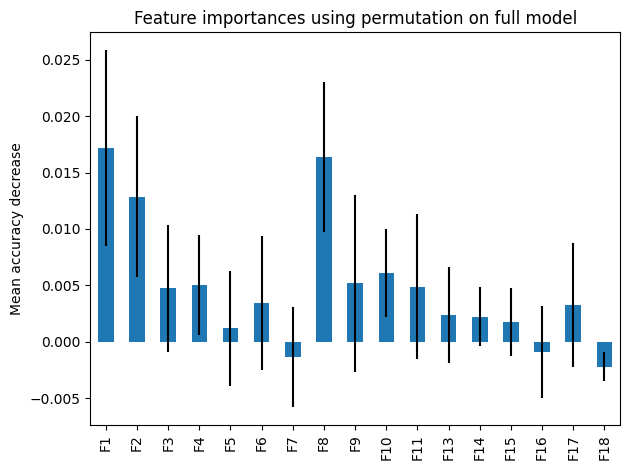

In [114]:
permutation_importance_function(rf_model, cfa_test_X, cfa_test_y)

In [115]:
# show features that are important from cfa data

n = 7
top_features = {}
for factor in cfa_loadings.columns:
    top = cfa_loadings[factor].abs().nlargest(n)
    top_features[factor] = [f"{feat}  ({cfa_loadings.loc[feat, factor]:+.2f})" for feat in top.index]

pd.DataFrame(top_features, index=[f"#{i+1}" for i in range(n)])

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F13,F14,F15,F16,F17,F18
#1,bmi (+1.11),how_noticeable_is_sleep_problem_impacting_qual...,rmeq_total_score (+1.07),difficulty_being_active_in_evening_fosq (+1.03),trouble_focusing_freq_phq (+1.00),worry_too_much_diff_things_freq_gad (+0.98),i_am_easily_fati_fss (+1.21),fati_interferes_with_work_fam_social_fss (+1.26),family_history_of_depression_mdhx (+0.99),pain_or_fatigue_mdhx (+0.95),gastrointestinal_problem_or_surgery_mdhx (+0.97),dental_problems_mdhx (+0.95),tonsillectomy_or_adenoidectomy_mdhx (+0.86),allergies_or_sinus_problems_mdhx (+0.93),asthma_mdhx (+0.94),hypertension_mdhx (+0.96),dream_recall_frequency_rarely_or_never (+0.86)
#2,age (+1.09),map_likelihood_ration (+1.07),sleep_made_you_irritable_isq (+1.03),difficulty_watching_a_movie_fosq (+1.03),poor_appetite_overeat_freq_phq (+1.00),feeling_anxious_freq_gad (+0.98),lower_motivation_when_fati_fss (+1.13),fati_top_three_disabling_sympts_fss (+1.26),family_history_of_anxiety_mdhx (+0.99),psychiatric_or_mental_health_problem_mdhx (+0...,hypercholesterolemia_mdhx (+0.96),ear_nose_and_throat_problem_or_surgery_other_m...,age (+0.00),pulmonary_problem_other_mdhx (+0.88),cardiovascular_problem_other_mdhx (+0.93),dream_recall_frequency_infrequent (+0.95),age (+0.00)
#3,breathing_stops_map (+1.08),sleep_problem_intereferes_with_daily_functioni...,sleep_made_you_fatigued_isq (+1.02),effect_on_desire_for_intimacy_or_sex_fosq (+1...,feel_bad_abt_yourself_freq_phq (+1.00),not_able_to_control_worrying_freq_gad (+0.97),exercise_brings_fati_fss (+1.07),fati_causes_freq_probs_for_me_fss (+1.25),family_history_of_sleep_apnea_mdhx (+0.98),urologic_or_kidney_problem_mdhx (+0.91),endocrine_or_metabolic_problem_mdhx (+0.96),nasal_jaw_or_apnea_surgery_mdhx (+0.92),bmi (+0.00),age (+0.00),chronic_obstructive_pulmonary_disease_mdhx (+...,oophorectomy_bilateral_mdhx (+0.94),bmi (+0.00)
#4,snorting_gasping_map (+1.08),how_worried_about_current_sleep_problem_isi (...,sleep_affected_other_important_parts_of_life_i...,difficulty_being_active_in_morning_fosq (+1.02),slow_move_or_speak_freq_phq (+0.95),trouble_relaxing_freq_gad (+0.97),easily_annoyed_freq_gad (+0.88),fati_interferes_with_responsibilities_fss (+1...,family_history_of_insomnia_mdhx (+0.98),age (+0.00),type_2_diabetes_mdhx (+0.95),age (+0.00),sex (+0.00),bmi (+0.00),age (+0.00),congestive_heart_failure_mdhx (+0.93),sex (+0.00)
#5,frequent_tossing_turning_map (+1.07),how_satisfied_with_curr_sleep_pattern_isi (+1...,sleep_caused_trouble_concentrating_isq (+1.02),relationships_with_family_or_friends_affected_...,thought_you_would_be_better_dead_freq_phq (+0...,age (+0.00),cant_sit_still_freq_gad (+0.80),fati_interferes_with_phys_function_fss (+1.23),medical_problem_or_surgery_other_mdhx (+0.98),bmi (+0.00),neurologic_problem_mdhx (+0.95),bmi (+0.00),sw_9am_start_diff (+0.00),sex (+0.00),bmi (+0.00),age (+0.00),sw_9am_start_diff (+0.00)
#6,map_index_1_apnea_score (+1.07),diff_staying_asleep_isi (+1.02),how_sleepy_do_you_feel_during_the_day_isq (+1...,difficulty_visiting_family_or_friends_in_their...,age (+0.00),bmi (+0.00),feel_as_if_awful_might_happen_freq_gad (+0.80),fati_prevents_sustained_phys_func_fss (+1.23),family_history_of_fibromyalgia_or_chronic_fati...,sex (+0.00),age (+0.00),sex (+0.00),sw_5pm_end_diff (+0.00),sw_9am_start_diff (+0.00),sex (+0.00),bmi (+0.00),sw_5pm_end_diff (+0.00)
#7,frequent_wakenings_map (+1.07),problems_waking_up_too_early_isi (+0.99),difficulty_operating_motor_vehicles_for_short_...,difficulty_operating_motor_vehicles_for_long_d...,bmi (+0.00),sex (+0.00),age (+0.00),ess_chance_of_dozing_car_passenger_hr (+0.94),family_history_of_restless_leg_syndrome_mdhx ...,sw_9am_start_diff (+0.00),bmi (+0.00),sw_9am_start_diff (+0.00),nasal_congestion_stuffiness_nose (+0.00),sw_5pm_end_diff (+0.00),sw_9am_start_diff (+0.00),sex (+0.00),nasal_congestion_stuffiness_nose (+0.00)


In [116]:
top_n = 5  # top features per factor

# EFA: collect unique top features across all factors
fa_top_features = set()
for col in fa_loadings.columns:
    fa_top_features.update(fa_loadings[col].abs().nlargest(top_n).index)
fa_top_features = list(fa_top_features)
fa_top_df = encoded_features[fa_top_features].copy()
fa_top_df["ahi"] = encoded_target.values

# CFA: collect unique top features across all factors
cfa_top_features = set()
for col in cfa_loadings.columns:
    cfa_top_features.update(cfa_loadings[col].abs().nlargest(top_n).index)
cfa_top_features = list(cfa_top_features)
cfa_top_df = encoded_features[cfa_top_features].copy()
cfa_top_df["ahi"] = encoded_target.values

print(f"EFA top df: {fa_top_df.shape}  ({len(fa_top_features)} unique features)")
print(f"CFA top df: {cfa_top_df.shape}  ({len(cfa_top_features)} unique features)")
display(fa_top_df.head())

EFA top df: (1687, 79)  (78 unique features)
CFA top df: (1687, 69)  (68 unique features)


,fati_interferes_with_phys_function_fss,fati_interferes_with_work_fam_social_fss,diff_falling_asleep_isi,ess_chance_of_dozing_tv,troub_slp_nose,family_history_of_anxiety_mdhx,ess_chance_of_dozing_in_a_car_while_stopped_for_few_minutes_in_traffic,feel_sleep_unrefreshing_isq,ess_chance_of_dozing_lying_down_in_afternoon_when_circumstances_permit,not_enough_air_excercise_nose,...,latency_sw,breathing_stops_map,fati_causes_freq_probs_for_me_fss,sleep_caused_trouble_concentrating_isq,ess_chance_of_dozing_sitting_quietly_after_lunch_without_alcohol,snorting_gasping_map,frequent_daytime_sleepiness,difficulty_being_active_in_evening_fosq,family_history_of_other_psychiatric_illness_mdhx,ahi
0,4.0,3.0,1.0,2.0,2.0,0,0.0,4.0,2.0,0.0,...,0.0,0.0,3.0,2.0,1.0,1.0,0.0,3.0,0,0.3
1,6.0,6.0,1.0,1.0,1.0,0,0.0,4.0,2.0,0.0,...,0.0,0.0,6.0,4.0,0.0,0.0,1.0,1.0,0,0.4
2,4.0,4.0,4.0,0.0,4.0,0,0.0,4.0,1.0,0.0,...,2.0,0.0,4.0,4.0,0.0,0.0,1.0,3.0,0,1.0
3,1.0,1.0,2.0,1.0,3.0,1,0.0,4.0,0.0,0.0,...,2.0,0.0,1.0,1.0,1.0,0.0,1.0,2.0,0,3.9
4,4.0,3.0,0.0,2.0,1.0,0,0.0,1.0,1.0,0.0,...,0.0,0.0,2.0,3.0,0.0,0.0,1.0,2.0,0,1.3


In [117]:
fa_top_df.to_csv("../../data/processed/mlflow/mlflow_fa_top_features_dataset_v1.csv", index=False)
cfa_top_df.to_csv("../../data/processed/mlflow/mlflow_cfa_top_features_dataset_v1.csv", index=False)

## **MLFlow Integrations**

In [118]:
# v1  dataset

encoded_dataset_path = "../../data/processed/mlflow/mlflow_dataset_v1.csv"
enc_dataset = mlflow.data.from_pandas(
    encoded_df,
    source=encoded_dataset_path,
    name="encoded_dataset_v1",
    targets="ahi"
)

# fa v1 dataset

fa_dataset_path = "../../data/processed/mlflow/mlflow_factor_dataset_v1.csv"
fa_dataset = mlflow.data.from_pandas(
    fa_df,
    source=fa_dataset_path,
    name="fa_dataset_v1",
    targets="ahi"
)

# cfa v1 dataset

cfa_dataset_path = "../../data/processed/mlflow/mlflow_cfa_dataset_v1.csv"
cfa_dataset = mlflow.data.from_pandas(
    cfa_df,
    source=cfa_dataset_path,
    name="cfa_dataset_v1",
    targets="ahi"
)


# fa top features 

fa_top_path = "../../data/processed/mlflow/mlflow_fa_top_features_dataset_v1.csv"
fa_top_dataset = mlflow.data.from_pandas(
    fa_top_df,
    source=fa_top_path,
    name="fa_top_features_dataset_v1",
    targets="ahi"
)

#cfa top features

cfa_top_path = "../../data/processed/mlflow/mlflow_cfa_top_features_dataset_v1.csv"
cfa_top_dataset = mlflow.data.from_pandas(
    cfa_top_df,
    source=cfa_top_path,
    name="cfa_top_features_dataset_v1",
    targets="ahi"
)



/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource s

In [120]:
import mlflow.sklearn
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.ensemble import HistGradientBoostingClassifier


mlflow.set_experiment("dataset-comparison-v1")

# ── prepare splits for datasets that don't have them yet ──────────────────────
enc_X = encoded_df.drop(columns=["ahi"])
enc_y = convert_ahi(encoded_df["ahi"], threshold=15)
enc_X_train, enc_test_X, enc_train_y, enc_test_y = train_test_split(
    enc_X, enc_y, test_size=0.2, random_state=42
)

fa_top_X = fa_top_df.drop(columns=["ahi"])
fa_top_y = convert_ahi(fa_top_df["ahi"], threshold=15)
fa_top_X_train, fa_top_test_X, fa_top_train_y, fa_top_test_y = train_test_split(
    fa_top_X, fa_top_y, test_size=0.2, random_state=42
)

cfa_top_X = cfa_top_df.drop(columns=["ahi"])
cfa_top_y = convert_ahi(cfa_top_df["ahi"], threshold=15)
cfa_top_X_train, cfa_top_test_X, cfa_top_train_y, cfa_top_test_y = train_test_split(
    cfa_top_X, cfa_top_y, test_size=0.2, random_state=42
)

# ── dataset registry ──────────────────────────────────────────────────────────
trials = [
    ("encoded_baseline",  enc_dataset,     enc_X_train,     enc_test_X,     enc_train_y,     enc_test_y),
    ("efa_factors",       fa_dataset,      fa_X_train,      fa_test_X,      fa_train_y,      fa_test_y),
    ("cfa_factors",       cfa_dataset,     cfa_X_train,     cfa_test_X,     cfa_train_y,     cfa_test_y),
    ("efa_top_features",  fa_top_dataset,  fa_top_X_train,  fa_top_test_X,  fa_top_train_y,  fa_top_test_y),
    ("cfa_top_features",  cfa_top_dataset, cfa_top_X_train, cfa_top_test_X, cfa_top_train_y, cfa_top_test_y),
]

rf_params = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

hgb_params = dict(
    max_iter=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
)



# ── run one MLflow run per dataset ────────────────────────────────────────────
mlflow.sklearn.autolog(log_models=False, silent=True)

print(f"{'dataset':<25}  {'acc':>6}  {'auc':>6}  {'f1':>6}  {'n_features':>10}")
print("-" * 62)
for name, mlflow_ds, X_train, X_test, y_train, y_test in trials:
    with mlflow.start_run(run_name=name):
        mlflow.log_input(mlflow_ds, context="training")
        mlflow.log_param("n_features", X_train.shape[1])

        rf_model = RandomForestClassifier(**rf_params)
        rf_model.fit(X_train, y_train)

        y_pred = rf_model.predict(X_test)
        y_prob = rf_model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        f1  = f1_score(y_test, y_pred)

        mlflow.log_metrics({"test_accuracy": acc, "test_roc_auc": auc, "test_f1": f1})
        print(f"{name:<25}  {acc:>6.3f}  {auc:>6.3f}  {f1:>6.3f}  {X_train.shape[1]:>10}")
        
for name, mlflow_ds, X_train, X_test, y_train, y_test in trials:
    with mlflow.start_run(run_name=f"{name}_hgb"):
        mlflow.log_input(mlflow_ds, context="training")
        mlflow.log_param("n_features", X_train.shape[1])

        hgb_model = HistGradientBoostingClassifier(**hgb_params)
        hgb_model.fit(X_train, y_train)

        y_pred = hgb_model.predict(X_test)
        y_prob = hgb_model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        f1  = f1_score(y_test, y_pred)

        mlflow.log_metrics({"test_accuracy": acc, "test_roc_auc": auc, "test_f1": f1})
        print(f"{name}_hgb  {acc:>6.3f}  {auc:>6.3f}  {f1:>6.3f}  {X_train.shape[1]:>10}")


dataset                       acc     auc      f1  n_features
--------------------------------------------------------------
encoded_baseline            0.612   0.521   0.166         146
efa_factors                 0.494   0.486   0.374          18
cfa_factors                 0.621   0.507   0.264          17
efa_top_features            0.609   0.558   0.205          78
cfa_top_features            0.595   0.534   0.208          68
encoded_baseline_hgb   0.541   0.512   0.317         146
efa_factors_hgb   0.524   0.518   0.423          18
cfa_factors_hgb   0.536   0.502   0.343          17
efa_top_features_hgb   0.571   0.581   0.378          78
cfa_top_features_hgb   0.580   0.529   0.393          68
